In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_spss(r'C:\Users\Bilal\Desktop\Studentfitdata.sav')

In [7]:
data

,Key,Steps,Mode,Minutes,Graduated,GPA,Pulse
0,1.0,11157.0,1.0,9.35,1.0,4.00,67.47
1,2.0,11602.0,0.0,12.73,0.0,3.07,65.70
2,3.0,10609.0,1.0,10.00,1.0,4.00,67.23
3,4.0,14552.0,1.0,8.63,0.0,2.87,67.26
4,5.0,8770.0,0.0,15.33,1.0,2.76,64.87
...,...,...,...,...,...,...,...
143,144.0,12507.0,0.0,18.25,1.0,2.76,64.12
144,145.0,11442.0,1.0,8.00,1.0,3.80,68.09
145,146.0,12188.0,1.0,7.83,0.0,2.07,68.05
146,147.0,8693.0,1.0,6.98,0.0,2.43,69.06


In [8]:
data =data.drop(columns=['Key'])

In [9]:
data = data.drop_duplicates()
data = data.dropna()

In [10]:
data.shape

(145, 6)

In [11]:
variables_in_study = data[['Steps', 'Mode','Minutes','Graduated','GPA','Pulse']]
# standardizing features
scaler = StandardScaler() ## standardizing the variable is essential in ridge and lasso regression
scaler.fit(variables_in_study)
variables_in_study = scaler.transform(variables_in_study) #subtracts the mean and divides by the standard deviation

variables_in_study = pd.DataFrame(variables_in_study, columns = ['Steps', 'Mode','Minutes','Graduated','GPA','Pulse'])
independent_variables = variables_in_study[['Steps', 'Mode','Minutes','Graduated','Pulse']]
dependent_variable = variables_in_study['GPA']

In [12]:
independent_variables

,Steps,Mode,Minutes,Graduated,Pulse
0,0.225663,0.478345,-0.267917,0.877258,0.189406
1,0.368816,-2.090543,0.833552,-1.079702,-1.016224
2,0.049374,0.478345,-0.056096,0.877258,0.025931
3,1.317813,0.478345,-0.502550,-1.079702,0.046365
4,-0.542220,-2.090543,1.680836,0.877258,-1.581576
...,...,...,...,...,...
140,0.659949,-2.090543,2.632401,0.877258,-2.092437
141,0.317345,0.478345,-0.707853,0.877258,0.611717
142,0.557329,0.478345,-0.763252,-1.079702,0.584471
143,-0.566991,0.478345,-1.040249,-1.079702,1.272430


In [13]:
dependent_variable

0      1.274526
1     -0.157126
2      1.274526
3     -0.465008
4     -0.634343
         ...   
140   -0.634343
141    0.966644
142   -1.696537
143   -1.142349
144    0.273909
Name: GPA, Length: 145, dtype: float64

In [14]:
x_train, x_test, y_train, y_test = train_test_split(independent_variables, dependent_variable, test_size=0.3)

In [15]:
print('The student data shape is: ', data.shape)
print('x_train shape is: ',x_train.shape)
print('x_test shape is: ',x_test.shape)
print('y_train shape is: ',y_train.shape)
print('y_test shape is: ',y_test.shape)

The student data shape is:  (145, 6)
x_train shape is:  (101, 5)
x_test shape is:  (44, 5)
y_train shape is:  (101,)
y_test shape is:  (44,)


In [16]:
MAE_list=[]    #mean absolute error
MSE_list=[]    # mean squared error
RMSE_list=[]   # root mean squared error  
R_Squared_list=[]


def model_evaluation(y_test, predictions):
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse) # or mse**(0.5)  
    r2 = metrics.r2_score(y_test,predictions)
    
    MAE_list.append(mae)
    MSE_list.append(mse)
    RMSE_list.append(rmse)
    R_Squared_list.append(r2)
    
    print("Results of sklearn.metrics: \n")
    print("MAE:",mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R-Squared:", r2)

In [17]:
x_train=sm.add_constant(x_train)
regression_model = sm.OLS(y_train, x_train)
results = regression_model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GPA   R-squared:                       0.308
Model:                            OLS   Adj. R-squared:                  0.272
Method:                 Least Squares   F-statistic:                     8.456
Date:                Fri, 23 Feb 2024   Prob (F-statistic):           1.19e-06
Time:                        01:36:35   Log-Likelihood:                -124.43
No. Observations:                 101   AIC:                             260.9
Df Residuals:                      95   BIC:                             276.6
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0208      0.085      0.244      0.808      -0.148       0.190
Steps          0.0327      0.125      0.262      0.794      -0.215       0.281
Mode           0.0041      0.136      0.030      0.976      -0.266       0.274
Minutes       -0.7949      0.322     -2.469      0.015      -1.434      -0.156
Graduated      0.4415      0.094      4.674      0.000       0.254       0.629
Pulse         -0.5593      0.285     -1.962      0.053      -1.125       0.007
==============================================================================
Omnibus:                        5.822   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.054   Jarque-Bera (JB):                5.805
Skew:                          -0.547   Prob(JB):                       0.0549
Kurtosis:                       2.572   Cond. No.                         8.07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
print(results.rsquared)
print(results.rsquared_adj)
print(results.pvalues)
print(results.params)

0.3079861542195461
0.2715643728626802
const        0.808082
Steps        0.794035
Mode         0.975764
Minutes      0.015331
Graduated    0.000010
Pulse        0.052714
dtype: float64
const        0.020761
Steps        0.032685
Mode         0.004148
Minutes     -0.794907
Graduated    0.441519
Pulse       -0.559308
dtype: float64


In [21]:
n_samples = x_test.shape[0]
ones_column = np.ones((n_samples, 1))
x_test_with_ones = np.concatenate((ones_column, x_test), axis=1)
predictions = results.predict(x_test_with_ones)

In [22]:
model_evaluation(y_test, predictions)

Results of sklearn.metrics: 

MAE: 0.8402108867489677
MSE: 1.0511376301692315
RMSE: 1.0252500330013317
R-Squared: -0.043545570419240454


In [23]:
## Polynomial Regression

In [24]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
x_poly=poly_reg.fit_transform(x_train)
poly_reg.fit(x_poly,y_train)
lin_reg = LinearRegression()
lin_reg.fit(x_poly, y_train)

LinearRegression()

In [26]:
predictions = lin_reg.predict(poly_reg.fit_transform(x_test_with_ones))

In [27]:
model_evaluation(y_test, predictions)

Results of sklearn.metrics: 

MAE: 0.8104200901235772
MSE: 0.9821886371985055
RMSE: 0.9910543058775868
R-Squared: 0.02490542413594876


In [29]:
rdg = Ridge(alpha = 3)   ## alpha is lamda
rdg = rdg.fit(x_train, y_train)
predictions = rdg.predict(x_test_with_ones)

C:\Users\Bilal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [30]:
print(rdg.score(x_train, y_train)) #R-squared
print(rdg.coef_)
print(rdg.intercept_)

0.3012727564009605
[ 0.          0.1169767   0.04203773 -0.49217299  0.41848899 -0.305245  ]
0.020224604515950012


In [31]:
model_evaluation(y_test, predictions)

Results of sklearn.metrics: 

MAE: 0.8468228920624887
MSE: 1.0456281617451924
RMSE: 1.0225596128075822
R-Squared: -0.038075895274659155


In [33]:
lasso = Lasso(alpha=0.01)
lasso = lasso.fit(x_train, y_train) 
prediction = lasso.predict(x_test_with_ones)

C:\Users\Bilal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


In [34]:
print(lasso.score(x_train, y_train))
print(lasso.coef_)
print(lasso.intercept_)

0.30451921238974755
[ 0.          0.08619018  0.00681105 -0.59457164  0.42965683 -0.37147622]
0.020458954560235644


In [35]:
model_evaluation(y_test, predictions)

Results of sklearn.metrics: 

MAE: 0.8468228920624887
MSE: 1.0456281617451924
RMSE: 1.0225596128075822
R-Squared: -0.038075895274659155


In [36]:
## Decision Tree

In [37]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error
from sklearn.tree import export_text
import matplotlib.pyplot as plt

Decision Tree Regression RMSE - Training Set: 0.9971557801180905
Decision Tree Regression RMSE - Test Set: 1.0077449667198684
|--- value: [0.03]



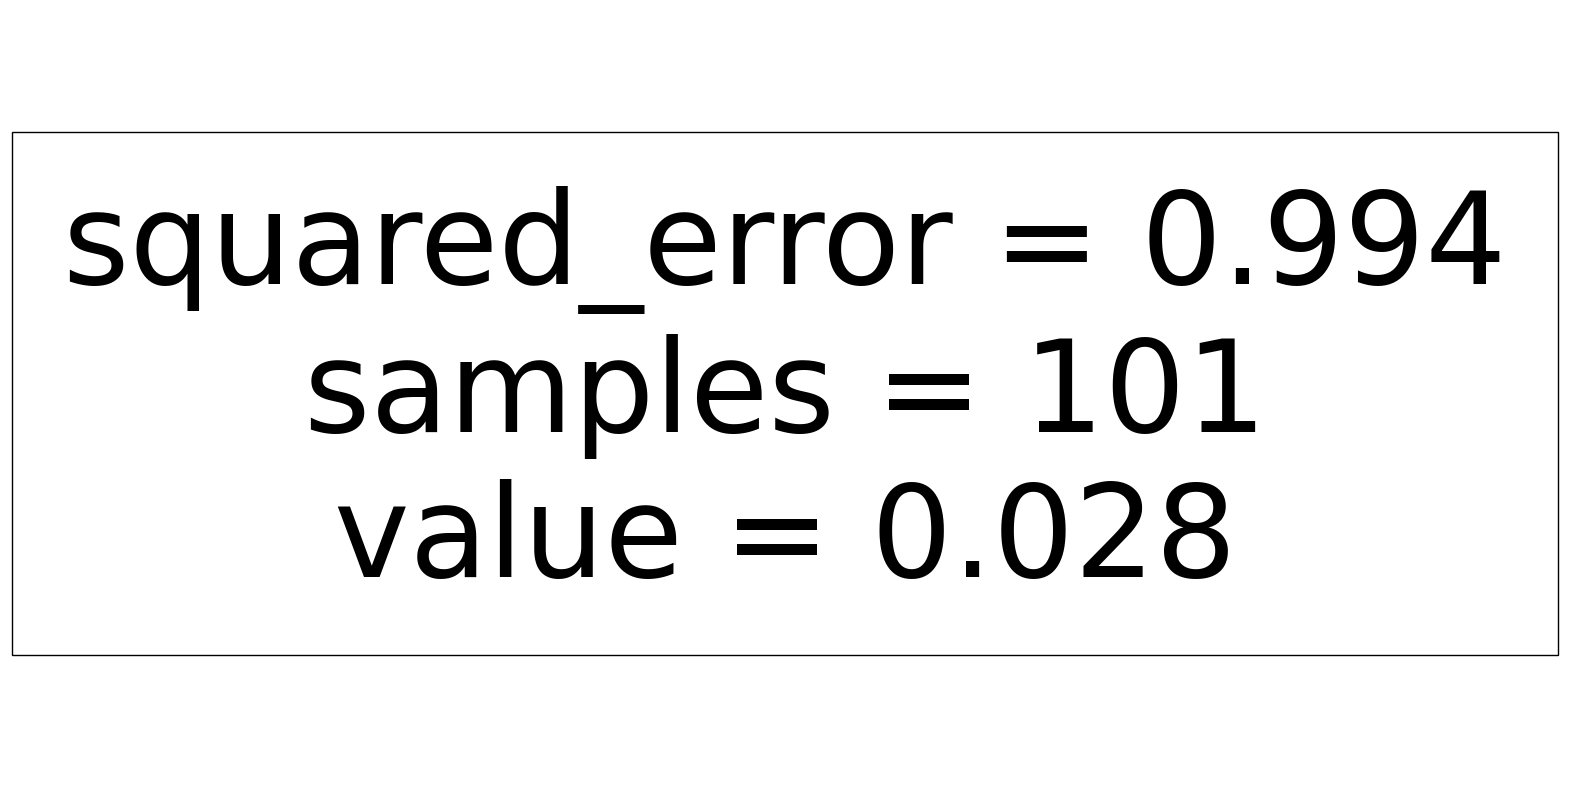

In [39]:
# Creating DecisionTreeRegressor instance
dtr = DecisionTreeRegressor(ccp_alpha=10)

# Fitting the decision tree model on the training data
dtr.fit(x_train, y_train)

# Add constant column to testing dataset
x_test = sm.add_constant(x_test)

# Get predictions for training and test sets
y_train_pred_tree = dtr.predict(x_train)
y_test_pred_tree = dtr.predict(x_test)

# Calculate RMSE for training set
rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))

# Calculate RMSE for test set
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))

# Print RMSE for training and test sets
print("Decision Tree Regression RMSE - Training Set:", rmse_train_tree)
print("Decision Tree Regression RMSE - Test Set:", rmse_test_tree)

# Print the decision tree
tree_rules = export_text(dtr, feature_names=x_train.columns.tolist())
print(tree_rules)

# Convert DataFrame columns to list
feature_names_list = x_train.columns.tolist()

plt.figure(figsize=(20, 10))  # Adjust figure size as needed
plot_tree(dtr, filled=True, feature_names=feature_names_list)  # Pass the list to 'feature_names' parameter
plt.show()

In [40]:
models_list = ['Multiple Linear Regression', 'Polynomial Regression', 'Ridge Regression', 'Lasso Regression' ]
models_list

['Multiple Linear Regression',
 'Polynomial Regression',
 'Ridge Regression',
 'Lasso Regression']

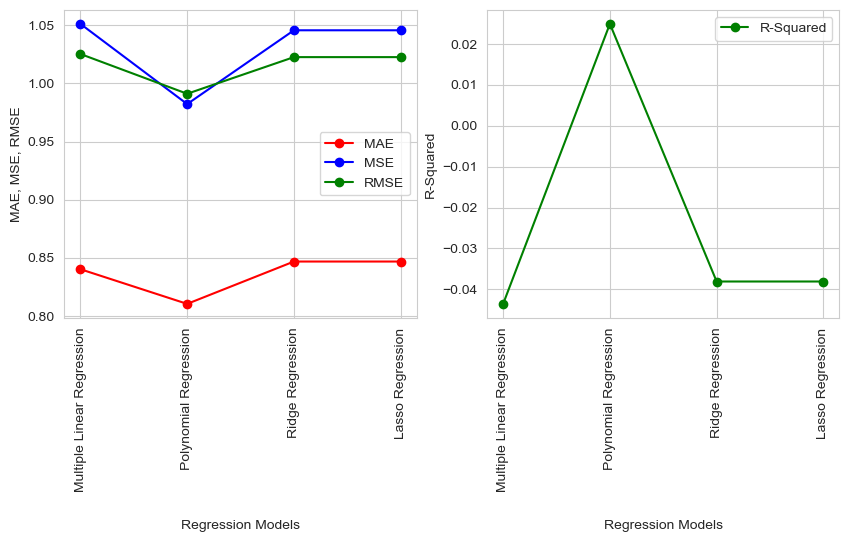

In [41]:
sns.set_style('whitegrid')

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(10,4));
ax1.plot(MAE_list,color='red', label='MAE', marker="o")
ax1.plot(MSE_list, color='blue', label='MSE', marker="o")
ax1.plot(RMSE_list,color='green', label='RMSE', marker="o")
ax2.plot(R_Squared_list,  color='green', label='R-Squared', marker="o")
ax1.legend()
ax2.legend()
ax1.set_xticks(ticks=range(len(MAE_list)))
ax2.set_xticks(ticks=range(len(R_Squared_list)))
ax1.set_xticklabels(models_list, rotation=90)
ax2.set_xticklabels(models_list, rotation=90)
ax1.set_xlabel('Regression Models', labelpad=20)
ax2.set_xlabel('Regression Models', labelpad=20)
ax1.set_ylabel('MAE, MSE, RMSE')
ax2.set_ylabel('R-Squared')
plt.show()

OLS Regression:

R-squared: 0.308 (low-moderate, indicates the model explains 30.8% of the variance in GPA)
Adjusted R-squared: 0.272 (slightly lower than R-squared, adjusts for overfitting)
F-statistic: 8.456 (significant at p<0.001, suggests the model is better than a model with only the intercept)
Individual coefficients:
Steps: positive, but small and not statistically significant (might not influence GPA)
Mode: positive and statistically significant, but small magnitude (weak influence)
Minutes: negative and statistically significant, but moderate magnitude (more minutes might be associated with lower GPA)
Graduated: positive and statistically significant (graduating might be associated with higher GPA)
Pulse: negative and statistically significant (higher pulse might be associated with lower GPA)
Diagnostics:
Omnibus test: not significant (data might not be normally distributed)
Jarque-Bera test: not significant (data might not be normally distributed)
Durbin-Watson statistic: 1.957 (close to 2, suggests no autocorrelation)
Interpretation: The OLS regression model provides a basic linear relationship between the predictor variables and GPA. However, the overall R-squared is low, indicating other factors not included in the model might be important. Some coefficients are statistically significant, but their magnitudes are small. Non-normality might be an issue.

Polynomial Regression:

R-squared: 0.0249 (very low, indicates the model explains almost no variance in GPA)
MAE, MSE, RMSE: slightly lower than OLS, but still high (model performance might not be significantly better)
Interpretation: Polynomial regression doesn't seem to improve the model significantly compared to OLS.

Lasso Regression:

R-squared: 0.3045 (similar to OLS, might not be better)
Coefficient values: some coefficients are set to zero due to regularization (variables might be excluded)
Interpretation: Lasso might provide some variable selection, but overall performance is not significantly different from OLS.

Decision Tree:

Training set RMSE: 0.9971 (high, suggests the model might be overfitting)
Test set RMSE: 1.0077 (slightly higher than training set, model might not generalize well)
Interpretation: The decision tree might be overfitting the training data and not performing well on unseen data.

Overall:

The OLS regression seems to be the most basic and interpretable model, but its R-squared is low.
Other models might not offer significant improvement in terms of performance or interpretability.
Consider exploring additional features, data transformations, and model selection techniques to improve the results.